In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data={
    "Study_Hours": [1,2,3,4,5,6,7,8,9,10],
    "Attendance": [60,85,70,95,65,80,80,75,88,72],
    "Marks": [32,42,47,58,61,67,76,79,88,91]
}


df=pd.DataFrame(data)
print(df)

   Study_Hours  Attendance  Marks
0            1          60     32
1            2          85     42
2            3          70     47
3            4          95     58
4            5          65     61
5            6          80     67
6            7          80     76
7            8          75     79
8            9          88     88
9           10          72     91


In [3]:
print('First Five Rows:')
df.head()

First Five Rows:


,Study_Hours,Attendance,Marks
0,1,60,32
1,2,85,42
2,3,70,47
3,4,95,58
4,5,65,61


In [4]:
print('Shape of Dataset')
df.shape

Shape of Dataset


(10, 3)

In [5]:
print('Information:')
df.info()

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_Hours  10 non-null     int64
 1   Attendance   10 non-null     int64
 2   Marks        10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes


In [6]:
print('Statistical Analysis:\n', df.describe())

Statistical Analysis:
        Study_Hours  Attendance      Marks
count     10.00000   10.000000  10.000000
mean       5.50000   77.000000  64.100000
std        3.02765   10.739336  19.790289
min        1.00000   60.000000  32.000000
25%        3.25000   70.500000  49.750000
50%        5.50000   77.500000  64.000000
75%        7.75000   83.750000  78.250000
max       10.00000   95.000000  91.000000


In [7]:
print('Check for Null')
df.isnull().sum()

Check for Null


,0
Study_Hours,0
Attendance,0
Marks,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates()

,Study_Hours,Attendance,Marks
0,1,60,32
1,2,85,42
2,3,70,47
3,4,95,58
4,5,65,61
5,6,80,67
6,7,80,76
7,8,75,79
8,9,88,88
9,10,72,91


Text(0.5, 1.0, 'Correleation Heatmap')

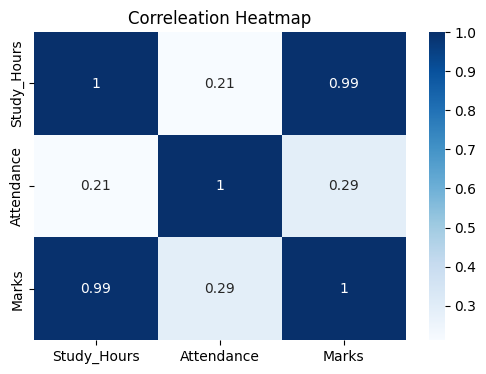

In [10]:
import seaborn as sns
df_corr=df.corr()
plt.figure(figsize=(6,4))
sns.heatmap(df_corr, annot=True, cmap='Blues')

plt.title('Correleation Heatmap')


In [11]:
x=df[['Study_Hours']]
y=df['Marks']

In [12]:
from sklearn.model_selection import train_test_split
x_train,  x_test,  y_train,  y_test = train_test_split(x,y, test_size=0.3, random_state=2)

In [13]:
x_test

,Study_Hours
4,5
1,2
5,6


In [14]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(x_train, y_train)

LinearRegression()

In [15]:
y_pred=model.predict(x_test)
y_pred

array([60.74159664, 41.1092437 , 67.28571429])

In [16]:
print('Intercept:', model.intercept_)
print('Slope:', model.coef_[0])

Intercept: 28.02100840336135
Slope: 6.544117647058823


In [17]:
from sklearn.metrics import root_mean_squared_error, r2_score, mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2=r2_score(y_test, y_pred)
print('RSME:', round(rmse, 3))
print('R2 Score:', round(r2,2))

RSME: 0.56
R2 Score: 1.0


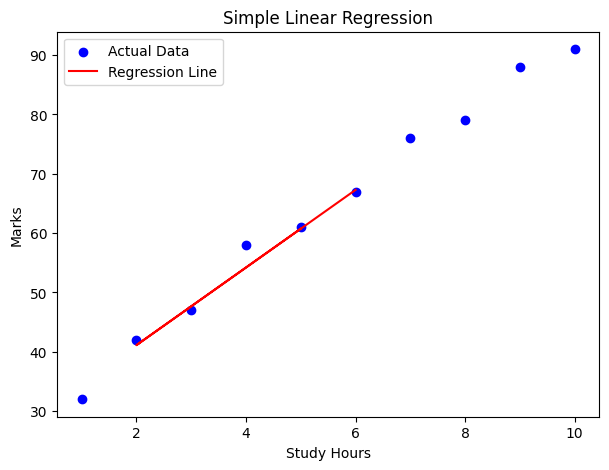

In [19]:
# Regression Line
plt.figure(figsize=(7, 5))
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x_test, y_pred,
         color='red', label='Regression Line')

plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

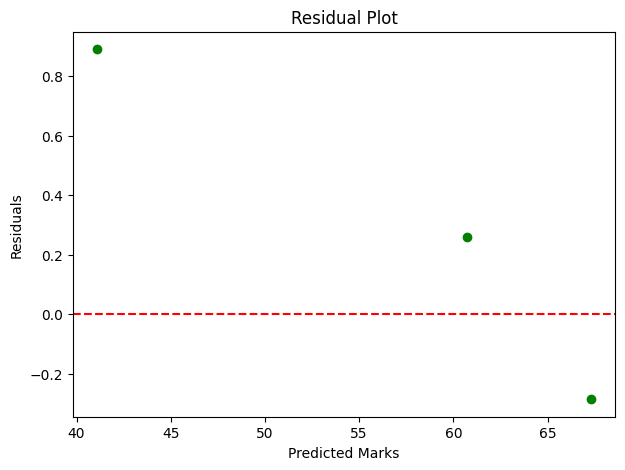

In [20]:
residuals = y_test - y_pred  # Calculate Residual

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Marks')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [21]:
x = df["Study_Hours"].values  # Independent Variable (Features)

y = df["Marks"].values  # Dependent Variable (Target)



In [22]:
x

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [23]:
# Calculate mean
x_mean = np.mean(x)
y_mean = np.mean(y)



In [24]:
x_mean

np.float64(5.5)

In [25]:
# Calculate slope
m = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)

# Calculate intercept
b = y_mean - m * x_mean

print("Slope =", m)
print("Intercept =", b)

Slope = 6.503030303030303
Intercept = 28.33333333333333


In [26]:
# Prediction
y_pred_numpy = m*x + b
y_pred_numpy

array([34.83636364, 41.33939394, 47.84242424, 54.34545455, 60.84848485,
       67.35151515, 73.85454545, 80.35757576, 86.86060606, 93.36363636])

In [27]:
# Feature Selection
x = df[['Study_Hours', 'Attendance']]  # Independent Variables
y = df['Marks']  # Dependent Variable

# Split Dataset
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [28]:
x_train

,Study_Hours,Attendance
0,1,60
7,8,75
2,3,70
9,10,72
4,5,65
3,4,95
6,7,80


In [29]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [30]:
# Prediction
y_pred = model.predict(x_test)
y_pred

array([88.61663717, 43.82159292, 68.17651917])

In [31]:
# Model Parameters
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

coef = pd.DataFrame(
    {'Feature': x.columns, 'Coefficient': model.coef_}
)

print(coef)

Intercept: 15.455339233038323
Coefficients: [6.32       0.18501475]
       Feature  Coefficient
0  Study_Hours     6.320000
1   Attendance     0.185015


In [32]:
# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Metrics Values of MLR:')

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print('MAE:', mae)
print('RMSE:', round(rmse, 2))
print('R2 Score:', round(r2, 2))

Metrics Values of MLR:
MAE: 1.2049164208456251
RMSE: 1.3
R2 Score: 1.0


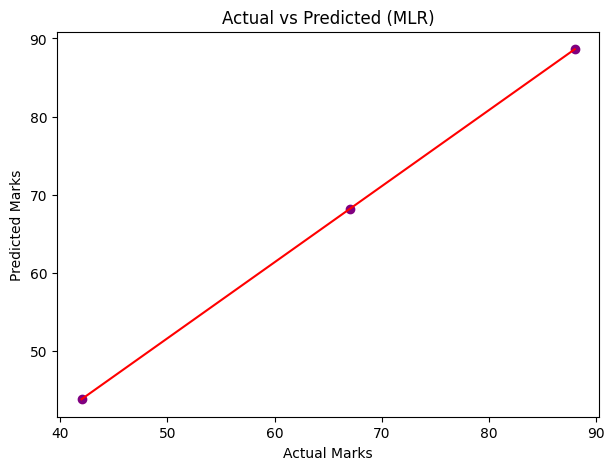

In [33]:
# Actual vs Predicted Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='Purple')

# Perfect Prediction Line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_pred.min(), y_pred.max()],
    color='red'
)

plt.xlabel('Actual Marks')
plt.ylabel('Predicted Marks')
plt.title('Actual vs Predicted (MLR)')
plt.show()

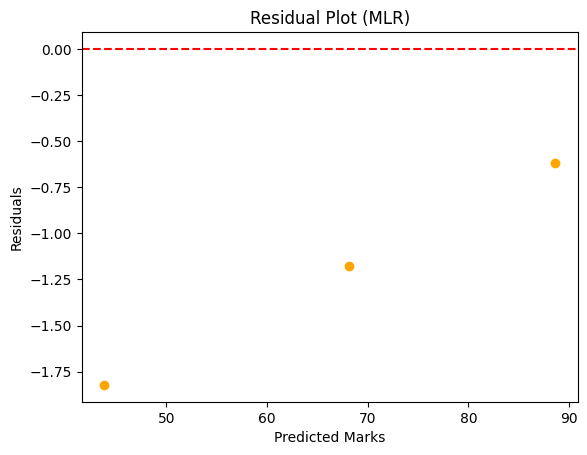

In [34]:
# Residual Plot
residuals = y_test - y_pred  # Calculate residual

plt.scatter(y_pred, residuals, color='Orange')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Marks')
plt.ylabel('Residuals')
plt.title('Residual Plot (MLR)')
plt.show()